# Quantified Self Project: Hypothetical Betting Data
Grant Turchin
CSPC 222, Spring 2025


## Introduction

**Disclaimer:** Since sports gambling is illegal in Washington besides Native American reservations, I want to note that these are hypothetical bets. 

Over the last year, I have been tracking my hypothetical sports betting data on an app called Action. Action allows me to track this data by selecting the bet I placed and letting me input the amount I wagered. Action lets you choose your dates and export the data into a CSV file for easy use. There are 505 instances(individual bets) in my data. The attributes in my table include: `League`-the name of the league of the bet, `Start Time`-the start time of the bet, `Game`-the game of the bet, `Pick Desc`-a description of what I bet, `Type`-the type of bet, `Period`-the duration of the bet (e.x. First half, game), `Odds`-the bets odds, `Odds/Spread/Total`-the spread, total, or odss of the ML of the bet, `Result`-the result of the bet,`Units Wagered`-the amount I wagered in units **(1unit=$10)**, `Units Net`-the amount of units I won or lost, `Money Wagered`-the amount I wagered in dollars, `Money Net`-the amount of money I won or lost. I also created a day mapping table that included: `day of week`-a numeric representation of the day of the week and `day name`-the name of the day of the week.  For my project, I wanted to see if I could use my betting data from December 1st to March 31st to determine what bets and if any insights could help me win more bets. With this in mind, I created my two hypotheses the first being I believed that my win rate was different on weekends and weekdays. The second was that my win rate was different in American vs. non-American sports. I wanted to classify whether my bet won or lost. The impacts of this information could shape my betting in the future. The stakeholders could be bettors, sports books, or platforms that predict bets. It could help them determine whether a bit will win or lose. It helps me determine what days or leagues I bet on to help give myself a better chance of winning. 

## Data Preparation
The original data contained a few issues that needed to be cleaned up. I did the following:
1. Converted the Start Time attribute from a string to DateTime object
2. Extracted New Features from Start Time
    - Date: the date of the bet
    - Day of week: A number (0 to 6) representing the day of the week
3. I changed the missing values in `Pick Desc` to "custom bet."
4. Deletes all rows in `Results` with push as it was skewing the data
5. I set the max odds to +-300: Lowering the total bets to 486
6. I renamed 'Odds/Spread/Total' to just 'Spread/Total'
7. Add a column called `Success` if `Result` was win=1 and loss=0 to allow easier calculation

In [425]:
from utils import clean_bet_data
import pandas as pd

df = pd.read_csv('bet_history.csv')
df_cleaned = clean_bet_data(df)



### Second Table: Day Mapping

I made a table that labeled the days with a string instead of a numeric value. The days of the week were assigned a 0 through 6 number which corresponded with a Monday through Sunday with Monday being 0.

In [426]:
from utils import create_day_mapping
day_mapping = create_day_mapping()


### Merging the Tables

After creating the new `day_mapping` table, I merged it with the clean bet history DataFrame on the 'Day of Week' column with a **left outer join**. 

In [427]:
from utils import merge_day_mapping

df_cleaned = merge_day_mapping(df_cleaned, day_mapping)


## Exploratory Data Analysis

### Data Aggregation by Result

I wanted to aggretated the data based on the outcome of the bet. This was tracked in the 'Result' attribute. 
I choose to sum import values such as:
- **Units Wagered:** Total number of betting units placed.
- **Units Net:** Net change in units from those bets.
- **Money Wagered:** Total dollars wagered.
- **Money Net:** Total profit or loss in dollars.
- **Total Wins** Total amount of wins
- **Total Losses** Total amount of losses
These provide an understanding of what were the impacts of the results of the bet. 

In [428]:
from utils import aggregate

wins, losses, summary = aggregate(df_cleaned)
print("Total Wins: ", wins, "\nTotal Losses: ", losses, "\n", summary)


Total Wins:  256 
Total Losses:  230 
   Result  Units Wagered  Units Net  Money Wagered  Money Net
0   loss        470.938  -470.9380        4709.38 -4709.3800
1    win        430.734   385.5836        4307.34  3855.8332


### Conclusion from aggregation

While I won more bets than I lost, I lost more money than I won showing that I lose more when I place bigger bets. 

### Visualisation

#### Average Daily Return by Day of the Week

This chart shows how much I typically win or lose **per day**, grouped by day of the week (Monday through Sunday).

For each day, I totaled all `Money Net` values. Then I averaged those daily totals by day name. THrough this data I was able to see the my exact average return by day of the week.

Example:  
If I win $10 on one Thursday and lose $50 on the next, my **average Thursday return** is **-20**.


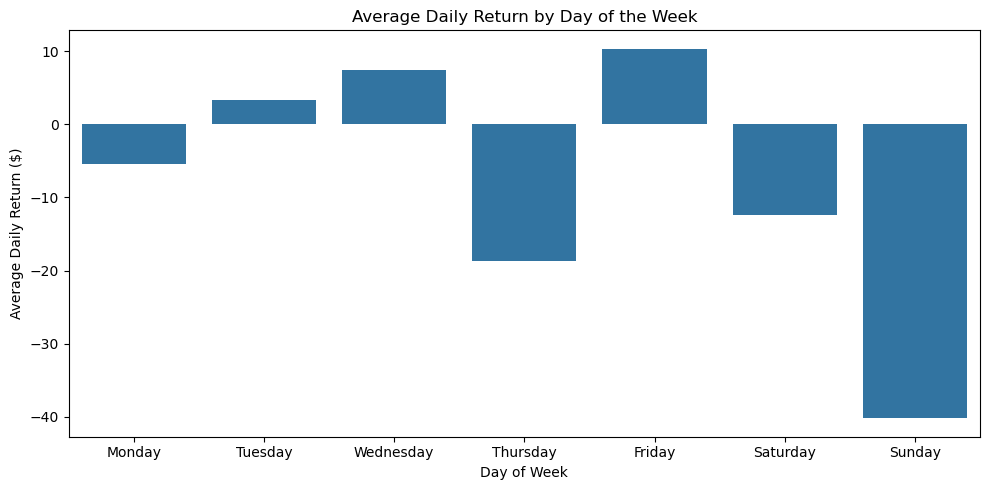

In [429]:
from utils import plot_avg_daily_return_by_day

plot_avg_daily_return_by_day(df_cleaned)



### Hypothesis Testing – Win Rate: Weekdays vs Weekends

From this graph I created the hypotheis that my win rates were different from weekday to weekends. This was a two-tailed test wit I then used a two-sample t-test to compare the average win rate (Success) for each group with a significance level of **0.05**.


I created a new feature:
- `Week Type`: Determines if the bet is on a weekday or weekend

#### Hypotheses:

- **H₀ (Null Hypothesis):** My win rate is the same on weekdays and weekends.
- **H₁ (Alternative Hypothesis):** My win rate is different between weekdays and weekends.

In [430]:
from utils import DOW, win_number, day_of_week_win_rate
df_cleaned = DOW(df_cleaned)
df_cleaned = win_number(df_cleaned)
day_of_week_win_rate(df_cleaned)




{'t_stat': 0.38130371987191,
 'p_value': 0.70314787595872,
 'conclusion': 'Fail to reject null hypothesis'}

### Results for First Hypothesis

**Graph:**

From the graph I can determine I only avereage a positive return on my hypothetical bets during weekdays. While this value represents how much I made or lost, it doesn't represent my win rate which might be different. 

**Hypothesis Test:**

My hypothesis test showed that my win rate on bets between weekdays and weekends has no significant difference. 

**Conclusion:**

My conculstion is that while I risk larger amounts of money during the weekends however, in terms of win rate it doesn't matter if I bet on a weekend or a weekday. 

### Distribution of Returns by League (Boxplot)

This boxplot displays the distribution of (`Money Net`) for each league with the region it is in. It shows:

1. The **mean** return of the bet based on its league
2. The **black lines** represent the **95% confidence interval of the mean**


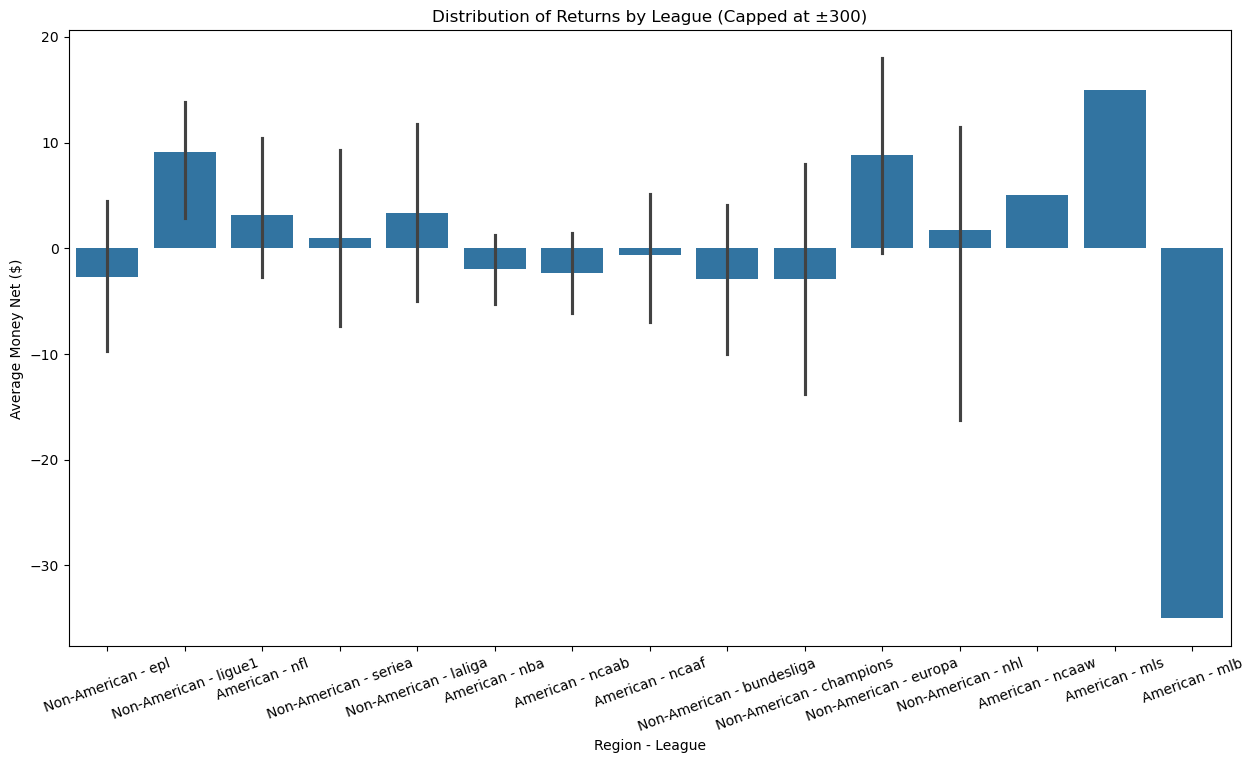

In [431]:
from utils import plot_league_return_barplot, countries
df_cleaned = countries(df_cleaned)
plot_league_return_barplot(df_cleaned, cap=300)




### Second Hypothesis testing

#### American Sports vs Non-American Sports

From this graph, I wanted to see if betting on American Sports leagues (e.x. NBA, NFL, MLB) than Non-American Sports leagues (e.x. NHL, La Liga, Serie A, EPL). I used a two-sample t-test at a level of significance at **0.15**.

I created a `Sport Region` column to classify each league.

**H₀ (Null Hypothesis):** My win rate is the same for American and Non-American sports.

**H₁ (Alternative Hypothesis):** My win rate is different between American and Non-American sports.



In [432]:
from utils import country_winrate
country_winrate(df_cleaned)

{'t_stat': -0.34074013564704164,
 'p_value': 0.7338068569354176,
 'conclusion': 'Fail to reject null hypothesis'}

### Results for the second hypothesis

#### Graph:

From the graph I was able to determine my most profitable was Champions Leguge while least was NCAAB. I am ignoring MLB and MLS for this conclusion because they have a small sample size so their the mean is not very reflective compared to other bets.

#### Hypothesis:

I found that there was no difference in my win rate between Non-American and American sports. 

#### Conclusion:

My win rate and return didn't matter whether I bet on American or Non-American sports. 

## Classification

In this section, I am building and evaluating a machine learning model to predict whether a bet will be successful (`Success = 1`) or not (`Success = 0`).

### Prepare Classification Data

I prepared the dataset for machine learning by performing the following steps:

1. **Dropped non-predictive columns** that do not contribute to classification, including `Start Time`, `Date`, `Pick Desc`, `Day Name`.
2. **Label encode** categorical variables such as `League`, `Sport Region`, and `Week Type` so that all features are numeric.
3. **Split the dataset** into training and test sets using a 70/30 split to evaluate the model with a random state of 0 for reproducibility
4. **Scaled the features** using `StandardScaler` to normalize the inputs for kNN.

#### Distribution of class labels

The distribution of my class labels rounded to the nearest whole percent are 53% wins and 47% losses.

#### Hypothesis

I believe that my machine learning model will have a very low accuracy due to there not being much difference in determining whether my bet wins or loses. 

#### Correlation Matrix

After creating my new chart to show the correlation to success to see how close the attributes correlated.

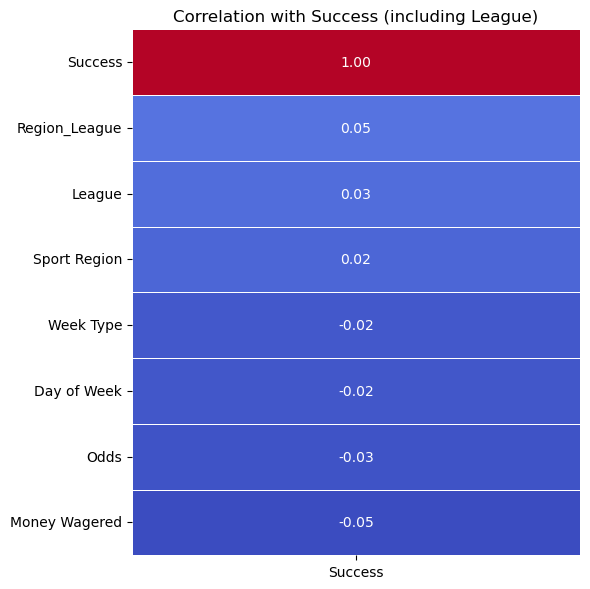

In [433]:
from utils import encode_split, correlation_with_success
df_encode = df_cleaned.copy()
df, X_train_scaled, X_test_scaled, y_train, y_test, X_train, X_test = encode_split(df_encode)
correlation_with_success(df)






### kNN Classifier

I trained a k-nearest neighbors model using the dataset. The following steps were taken:

1. Ran a loop to find the best k
2. Set the best k as my k
2. Had a `KNeighborsClassifier` with `k=5`.
2. Trained the model on the scaled training set.
3. Predicted outcomes for the test set.
4. Evaluated performance using:
   - **Accuracy score**
   - **Confusion matrix** (true/false positives and negatives)


In [434]:
from utils import kNN_training
k, accuracy, matrix = kNN_training(X_train_scaled, X_test_scaled, y_train, y_test)
print("Best k: ", k, "\naccuracy score: ", accuracy, "\nmatrix:\n ", matrix)





Best k:  3 
accuracy score:  0.541095890410959 
matrix:
  [[35 34]
 [33 44]]


## Decision Tree Classifier

We trained a decision tree classifier to predict betting success. The following steps were taken:

1. Initialized a `DecisionTreeClassifier` with `max_depth=4`
2. Trained the model using the training data.
3. Predicted on the test set and evaluated using accuracy and a confusion matrix.



accuracy socre:  0.4589041095890411 
 [[43 26]
 [53 24]]
None


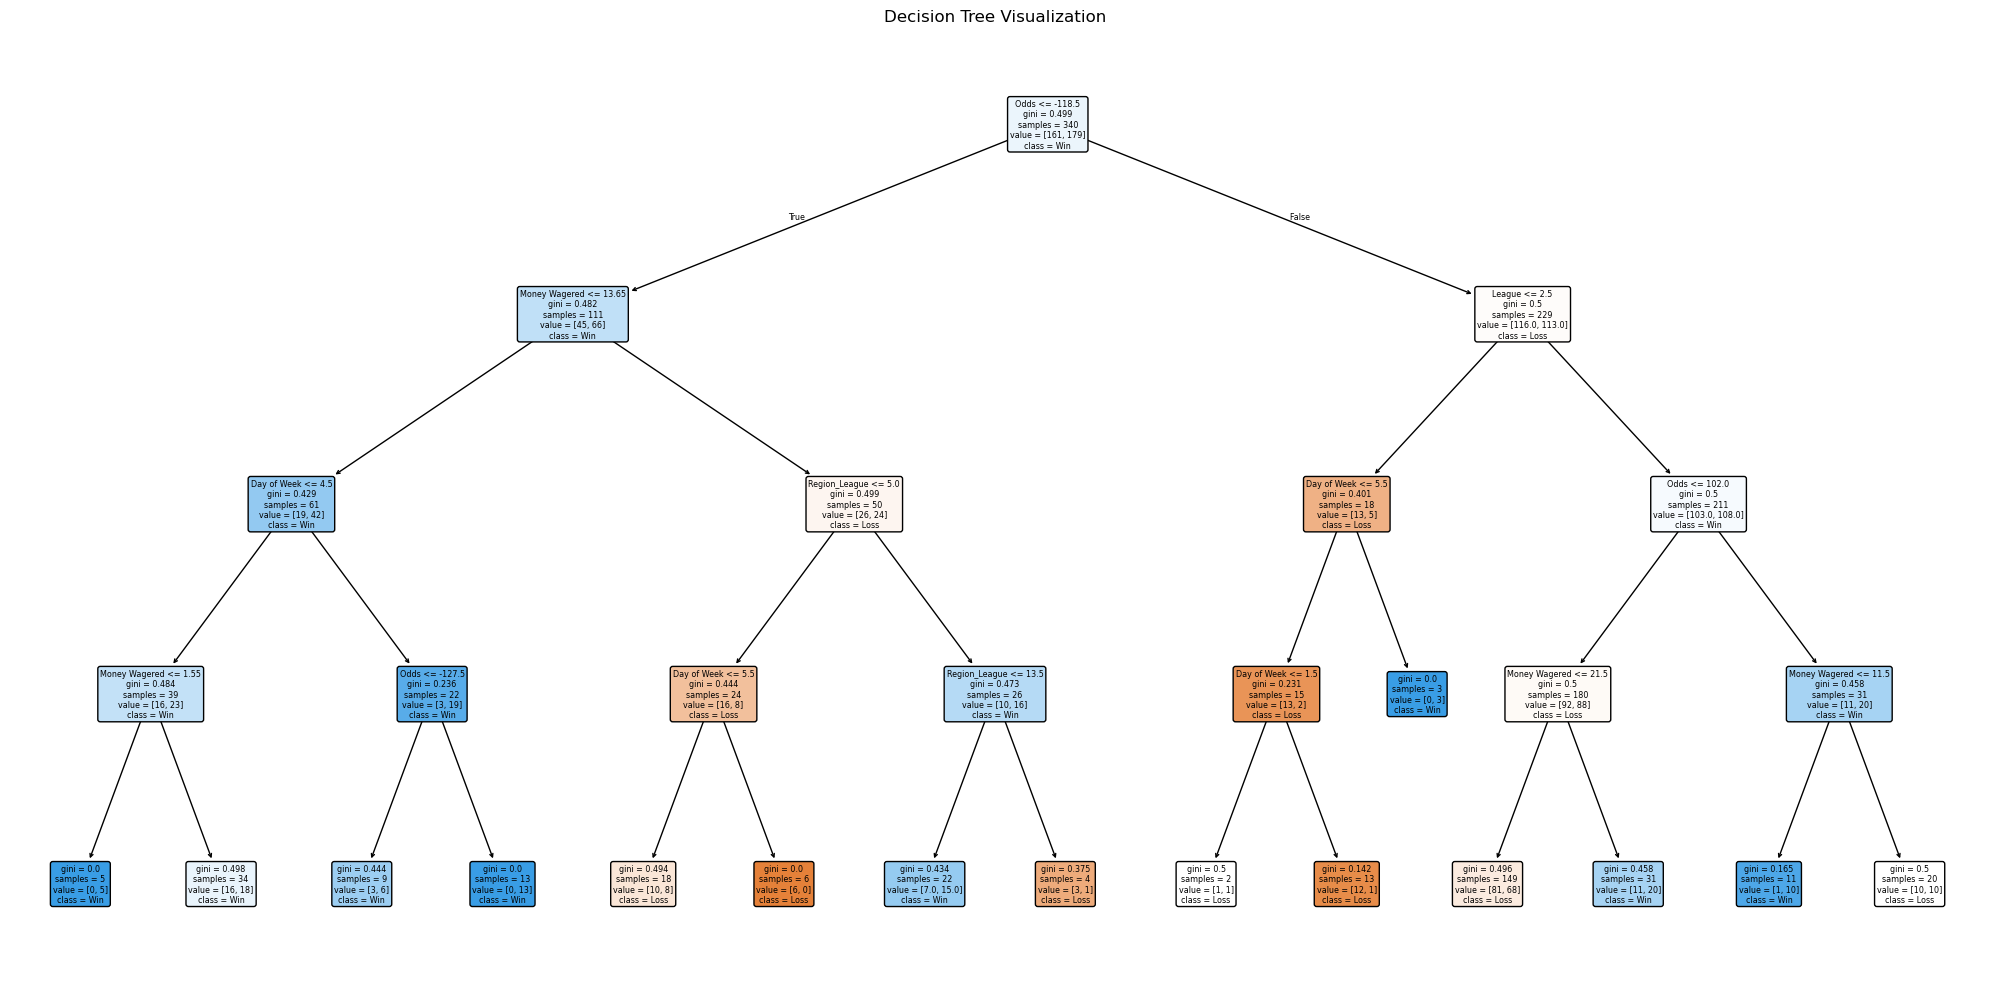

In [435]:
from utils import decision_tree, plot_decision_tree
accuracy, matrix, d_tree = decision_tree(X_train, X_test, y_train, y_test)
print(print("accuracy socre: ", accuracy, "\n", matrix))
plot_decision_tree(d_tree, X_train.columns)



### Results / Conclusion

#### Challenges

During classification, I had to change my model a few times. Initially, during my first test, I had a 'Result' column that kept my accuracy score at 1.0. After removing the feature I found my accuracy score still hadn't changed so I removed 'Units Net' and 'Money Net'. That finally changed it to the current accuracy score of my tests.

#### kNN

During my test, I wanted to use the 'k' value that had the best accuracy score. The accuracy score of **0.541** is very low telling me that the kNN model had difficulty predicting the outcome of the mock bets. The proportion of picked wins and losses was about the same. It shows that there wasn't a pattern when it came to my bets.

#### Decision Tree

My decision tree had an accuracy of  **0.459**.  The model was bad at predicting wins but good at predicting losses compared to the kNN which was about even. I am unsure about the cause of this disparity.

#### Conclusion

The kNN had a better accuracy score than the decision tree indicating that it could be the better choice. They were both not very good however, with accuracy lower than 0.55 for both. In conclusion, my hypothetical betting wins and losses were pretty random and this was expressed through the models accuracy. 

## Conclusion

My project showed that my betting data is very random and that my bets with the data I have are not very indicative of my results. The classification approach I developed was trying to determine `Success` using kNN and a decision tree. The performance of my classifers was extremely bad which was in line with my hypothesis. In the future to improve I could only try to predict the outcome in one league instead of in general. The bets were too broad and varied to have an actual prediction. For the stakeholders the project shows with only the data from bets it is almost impossible to predict the outcomes. I could write pages about the ethics of betting but in general, the main point is that you lose more money than you win and the sportsbooks platforms thrive and get their customers addicted. My sources were action.com, the matplotlib website, the pandas website, and Grammarly to help with spell check.